<font size="6"><center style="color:#1B4F72"><br/>
Técnicas de Simulación</center></font>
<font size="4"><center style="color:#1B4F72"><br/>
Máster en Ingeniería Matemática</center></font>

<font size="5"><center><span style="color:#117864">***Nombre y Apellidos: Siria Catherine Iñiguez Brito***</span></center></font>

<font size="5"><center><span style="color:#1B4F72">***Práctica 1: Generadores de números pseudoaleatorios***</span></center></font>

### Importamos las librerías necesarias

In [1]:
import numpy as np
import pandas as pd
from math import sin, cos, sqrt, log, exp, pi
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp
from scipy import stats
from scipy.stats import shapiro, norm
from statsmodels.sandbox.stats.runs import runstest_1samp

In [2]:
# 1. Definición de la Paleta
PALETA = {
    'principal': '#2E4053',   # Azul Medianoche
    'secundario': '#5DADE2',  # Azul Acero
    'teorico': '#E74C3C',     # Rojo Coral
    'fondo': '#F4F6F7',       # Gris claro
    'texto': '#1B2631',       # Negro Azulado
    'rejilla': '#D5DBDB'      # Gris medio
}

# 2. Configuración Global de Estilo
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': PALETA['fondo'],
    'axes.edgecolor': PALETA['rejilla'],
    'axes.labelcolor': PALETA['texto'],
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'xtick.color': PALETA['texto'],
    'ytick.color': PALETA['texto'],
    'grid.color': 'white',
    'grid.linestyle': '-',
    'font.family': 'sans-serif'
})


### Valores de los parámetros para el método congruencial

Considerad los siguientes valores para los parámetros en el método congruencial:  
* m=2**(31)-1
* a=16807
* b=0  

y la semilla inicial en todos los casos será:  
* x0=123456789

In [3]:
m = 2**(31)-1
a = 16807
b = 0
x0 = 123456789

## 1. Método congruencial.

In [4]:
# Definimos la funcion congruencial
def fCongruencial(x, a, b, m):
  return  (x*a + b) % m

# Definimos funcion para obtener N numero pseudoaleatorios U(0,1)
def fUniformeN(x, a, b, m, N):
  i = 0
  datos_u = []

  while i < N:
      x = fCongruencial(x, a, b, m)
      datos_u.append(x/m)
      i += 1

  return datos_u

1. Para comprobar que está correctamente programado, generar 100 valores U(0,1). Éstos deben cumplir:  

    * $\overline{x} = 0.47682692$
    * $S^2_n = 0.09155876$
    * $S^2_{n-1} = 0.09248360$
    * $u1 = 0.2184183 ~ u2 = 0.95631758 ~ u3 = 0.82950923 . . .$  
    

2. Justificar que los números generados proceden de una distribución U(0,1).


### 1.1 Comprobaciones para Congruencial


In [5]:
# Generacion de 100 valores de U(0,1)
N = 100
datos_u = fUniformeN(x0, a, b, m, N)

# Metricas
media = np.mean(datos_u)
desviacion = np.std(datos_u, ddof=1)     # Desviación típica muestral
varianza = np.var(datos_u)               # Varianza poblacional (sesgada)
cuasivarianza = np.var(datos_u, ddof=1)  # Varianza muestral (insesgada)

# Resultados
print("=" * 45)
print(f"{'RESULTADOS CONGRUENCIAL':^45}")
print("=" * 45)
print(f"{'Media':<15}       | {media:.8f}")
print(f"{'Desviación':<15}       | {desviacion:.8f}")
print(f"{'Varianza S^2_n':<15}       | {varianza:.8f}")
print(f"{'Cuasivarianza S^2_n-1':<15} | {cuasivarianza:.8f}")
print("-" * 40)
print(f"Primeros valores: u0={datos_u[0]:.8f}, u1={datos_u[1]:.8f}, u2={datos_u[2]:.8f}")

           RESULTADOS CONGRUENCIAL           
Media                 | 0.47682692
Desviación            | 0.30411116
Varianza S^2_n        | 0.09155876
Cuasivarianza S^2_n-1 | 0.09248360
----------------------------------------
Primeros valores: u0=0.21841830, u1=0.95631758, u2=0.82950923


### 1.2. Justificación para Congruencial

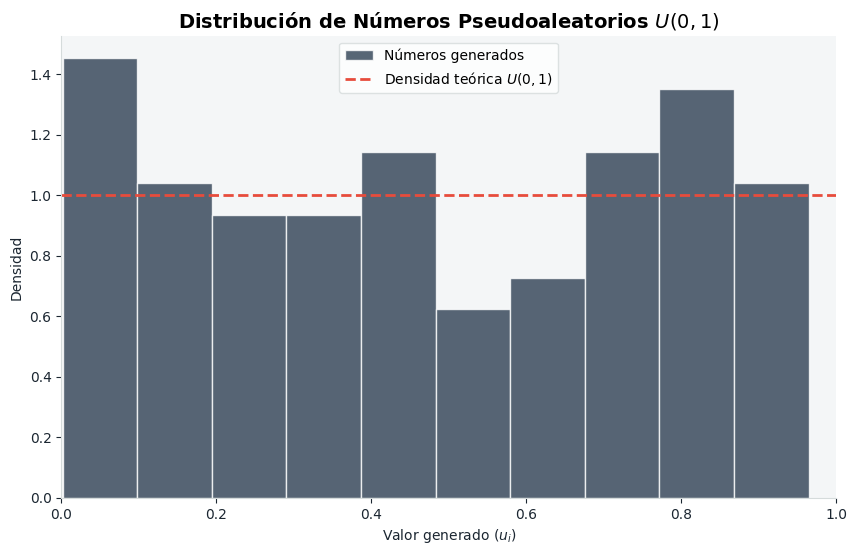

       TEST DE KOLMOGOROV-SMIRNOV       
H0: Los datos siguen una distribución U(0,1)
Estadístico D: 0.076896
p-valor:       0.568770
----------------------------------------
Conclusión: No se rechaza H0 (Sigue una distribución Uniforme)


         TESTS DE ALEATORIEDAD          
1. TEST DE RACHAS (Independencia):
   p-valor: 1.000000
   Conclusión: No hay patrones detectados (Secuencia aleatoria)

2. AUTOCORRELACIÓN (Lag 1):
   Coeficiente: 0.062612


In [6]:
# Histograma
plt.figure(figsize=(10, 6))

plt.hist(datos_u, bins=10, edgecolor='white', alpha=0.8,
         color=PALETA['principal'], density=True, label='Números generados')

plt.axhline(y=1, color=PALETA['teorico'], linestyle='--', linewidth=2,
            label='Densidad teórica $U(0,1)$') # Línea teórica


plt.title('Distribución de Números Pseudoaleatorios $U(0,1)$')
plt.xlabel('Valor generado ($u_i$)')
plt.ylabel('Densidad')
plt.legend(facecolor='white', edgecolor=PALETA['rejilla'])
plt.xlim(0, 1)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.show()

# Test de Kolmogorov-Smirnov
ks_statistic, ks_pvalue = stats.kstest(datos_u, 'uniform', args=(0, 1))
print("="*40)
print(f"{'TEST DE KOLMOGOROV-SMIRNOV':^40}")
print("="*40)
print(f"H0: Los datos siguen una distribución U(0,1)")
print(f"Estadístico D: {ks_statistic:.6f}")
print(f"p-valor:       {ks_pvalue:.6f}")
print("-" * 40)

if ks_pvalue > 0.05:
    print("Conclusión: No se rechaza H0 (Sigue una distribución Uniforme)")
else:
    print("Conclusión: Se rechaza H0 (No sigue una distribución Uniforme)")


# Test de Rachas
# Evaluamos si la secuencia de números por encima/debajo de la mediana es aleatoria
z_stat, p_value_runs = runstest_1samp(datos_u, cutoff='median')

print('\n')
print("="*40)
print(f"{'TESTS DE ALEATORIEDAD':^40}")
print("="*40)
print(f"1. TEST DE RACHAS (Independencia):")
print(f"   p-valor: {p_value_runs:.6f}")
if p_value_runs > 0.05:
    print("   Conclusión: No hay patrones detectados (Secuencia aleatoria)")
else:
    print("   Conclusión: Se detectan patrones (Secuencia NO aleatoria)")

# Análisis de Autocorrelación (Lag 1)
# Verifica si u_i está correlacionado con u_{i+1}
autocorr = np.corrcoef(datos_u[:-1], datos_u[1:])[0, 1]
print(f"\n2. AUTOCORRELACIÓN (Lag 1):")
print(f"   Coeficiente: {autocorr:.6f}")

Para evaluar si la secuencia de números pseudoaleatorios generada mediante el algoritmo congruencial es compatible con una distribución uniforme estándar $U(0, 1)$, se ha procedido a un análisis multidimensional basado en momentos, distribución empírica e independencia.

### A. Análisis Descriptivo (Métricas de Momento)
Desde una perspectiva teórica, una variable aleatoria $U(0,1)$ se caracteriza por una media $\mu = 0.5$ y una varianza $\sigma^2 = 1/12 \approx 0.0833$.

* **Tendencia Central:** La media obtenida ($0.4768$) se aproxima al valor teórico esperado ($\mu = 0.5$). La diferencia observada es pequeña y se atribuye al error estándar del muestreo propio de trabajar con una muestra finita ($N=100$).
* **Análisis de Dispersión:** Se calcula la **cuasivarianza muestral** ($S^2_{n-1}$) como estimador insesgado del parámetro poblacional. El valor obtenido ($0.092$) se compara con la varianza teórica de la distribución uniforme ($\sigma^2 = 1/12 \approx 0.0833$). Esta proximidad entre el estimador y el parámetro sugiere que la variabilidad intrínseca del generador se adecua al modelo teórico esperado.

### B. Evidencia Visual (Histograma de Densidad)
El análisis gráfico mediante el histograma de densidad permite observar la distribución de frecuencias relativas en el intervalo $[0, 1]$.  
* La comparación con la función de densidad teórica $f(u)=1$ sirve como una primera inspección visual que apoya la hipótesis de uniformidad.

### C. Contraste de Bondad de Ajuste (Test de Kolmogorov-Smirnov)
Para dotar de rigor estadístico a la observación visual, se aplica el test de **Kolmogorov-Smirnov (K-S)**, el cual mide la máxima diferencia entre la función de distribución acumulada empírica y la teórica. Las hipótesis planteadas son:
* $H_0$: Los datos proceden de una población con distribución $U(0, 1)$.
* $H_1$: Los datos proceden de una población con una distribución distinta.

Al obtener un p-valor de 0.568770 superior al nivel de significación prefijado ($\alpha = 0.05$), **no se dispone de evidencia estadística suficiente para rechazar la hipótesis nula**. Esto implica que los datos son estadísticamente compatibles con una distribución uniforme estándar bajo este nivel de confianza.

### D. Análisis de Pseudoindependencia
Dado que el algoritmo es determinista, se verifica si los valores se comportan de manera estocásticamente independiente:
* **Test de Rachas (Runs Test):** Evalúa la aleatoriedad en la alternancia de los valores respecto a la mediana. El p-valor de 1.0 es un resultado que indica que la secuencia no presenta patrones cíclicos, tendencias persistentes o rachas inusuales.
* **Autocorrelación:** El coeficiente de autocorrelación ($0.0626$) para un retardo de 1  cuantifica la dependencia lineal entre valores sucesivos. Al ser un valor muy cercano a cero, se confirma la ausencia de correlación serial, garantizando que el conocimiento de un número no permite predecir linealmente el valor del sucesor.

## 2. Generar una distribución triangular:
(con parámetros a elegir)
* Utilizando método basado en la inversa de la función de distribución.
* Y basado en el método de rechazo.   

<font size="1">Sugerencia: si os resulta más cómodo, hacerlo a mano y adjuntar una foto.</font>


### 2.1 Método basado en la inversa de la función de distribución.


Este procedimiento se fundamenta en el **teorema de la transformada inversa**, igualando la Función de Distribución Acumulada $F(x)$ a una variable uniforme $u \sim U(0,1)$ para obtener la variable aleatoria deseada a través de $x = F^{-1}(u)$.

#### A. Desarrollo Analítico (Caso General)
Se define una distribución triangular continua con parámetros $a$ (mínimo), $b$ (máximo) y $c$ (moda), donde $a < c < b$. La función de densidad $f(x)$ se compone de dos ramas lineales:

$$f(x) = \begin{cases} \frac{2(x-a)}{(b-a)(c-a)} & \text{si } a \le x < c \\ \frac{2(b-x)}{(b-a)(b-c)} & \text{si } c \le x \le b \end{cases}$$

**1. Obtención de la CDF ($F(x)$) por integración:**

Para el **primer tramo ($a \le x < c$)**, integramos la función de densidad desde el límite inferior:
$$F(x) = \int_{a}^{x} \frac{2(t-a)}{(b-a)(c-a)} dt = \frac{2}{(b-a)(c-a)} \left[ \frac{(t-a)^2}{2} \right]_{a}^{x} = \frac{(x-a)^2}{(b-a)(c-a)}$$

Para el **segundo tramo ($c \le x \le b$)**, la probabilidad acumulada es la suma del área total del primer tramo ($F(c)$) más la integral de la segunda rama:
$$F(x) = F(c) + \int_{c}^{x} \frac{2(b-t)}{(b-a)(b-c)} dt$$
Sabiendo que $F(c) = \frac{c-a}{b-a}$, y resolviendo la integral cuya primitiva es $-\frac{(b-t)^2}{2}$:
$$F(x) = \frac{c-a}{b-a} + \frac{2}{(b-a)(b-c)} \left[ -\frac{(b-t)^2}{2} \right]_{c}^{x} = 1 - \frac{(b-x)^2}{(b-a)(b-c)}$$

**2. Inversión de la función ($u = F(x)$):**

El punto de corte o umbral de probabilidad viene definido por $h = F(c) = \frac{c-a}{b-a}$. Despejando $x$ en ambos tramos, obtenemos la función generatriz:

* **Si $u \le \frac{c-a}{b-a}$:**
    $$u = \frac{(x-a)^2}{(b-a)(c-a)} \implies x = a + \sqrt{u(b-a)(c-a)}$$
* **Si $u > \frac{c-a}{b-a}$:**
    $$u = 1 - \frac{(b-x)^2}{(b-a)(b-c)} \implies x = b - \sqrt{(1-u)(b-a)(b-c)}$$




#### B. Desarrollo Analítico (Caso Particular)

### Parámetros seleccionados
*   **Mínimo ($a$):** 0
*   **Máximo ($b$):** 10
*   **Moda ($c$):** 7

### Función de Densidad de Probabilidad (PDF)
La función de densidad $f(x)$ define la forma del triángulo. Para los parámetros elegidos, la expresión es:

$$f(x) = \begin{cases} 0 & \text{si } x < 0 \\ \frac{2(x-a)}{(b-a)(c-a)} = \frac{2x}{70} & \text{si } 0 \leq x \leq 7 \\ \frac{2(b-x)}{(b-a)(b-c)} = \frac{2(10-x)}{30} & \text{si } 7 < x \leq 10 \\ 0 & \text{si } x > 10 \end{cases}$$

### Función de Distribución Acumulada (CDF)
Calculamos la probabilidad acumulada $F(x)$ integrando la función de densidad en cada tramo. Representa la probabilidad de que la variable tome un valor menor o igual a $x$:


$$F(x) = \begin{cases} 0 & \text{si } x < 0 \\ \frac{(x-a)^2}{(b-a)(c-a)} = \frac{x^2}{70} & \text{si } 0 \leq x \leq 7 \\ 1 - \frac{(b-x)^2}{(b-a)(b-c)} = 1 - \frac{(10-x)^2}{30} & \text{si } 7 < x \leq 10 \\ 1 & \text{si } x > 10 \end{cases}$$

### Obtención de la Función Inversa ($F^{-1}(u)$)
Para transformar los números pseudoaleatorios $u \in [0,1]$ en valores de la distribución triangular, igualamos $F(x) = u$ y despejamos $x$. El punto de corte en el eje de probabilidades viene dado por $h = \frac{c-a}{b-a} = 0.7$.

1. **Tramo creciente ($0 \leq u \leq 0.7$):**
   $$u = \frac{x^2}{70} \implies x^2 = 70u \implies x = \sqrt{70u}$$

2. **Tramo decreciente ($0.7 < u \leq 1$):**
   $$u = 1 - \frac{(10-x)^2}{30} \implies \frac{(10-x)^2}{30} = 1 - u \implies (10-x)^2 = 30(1-u)$$
   $$10 - x = \sqrt{30(1-u)} \implies x = 10 - \sqrt{30(1-u)}$$

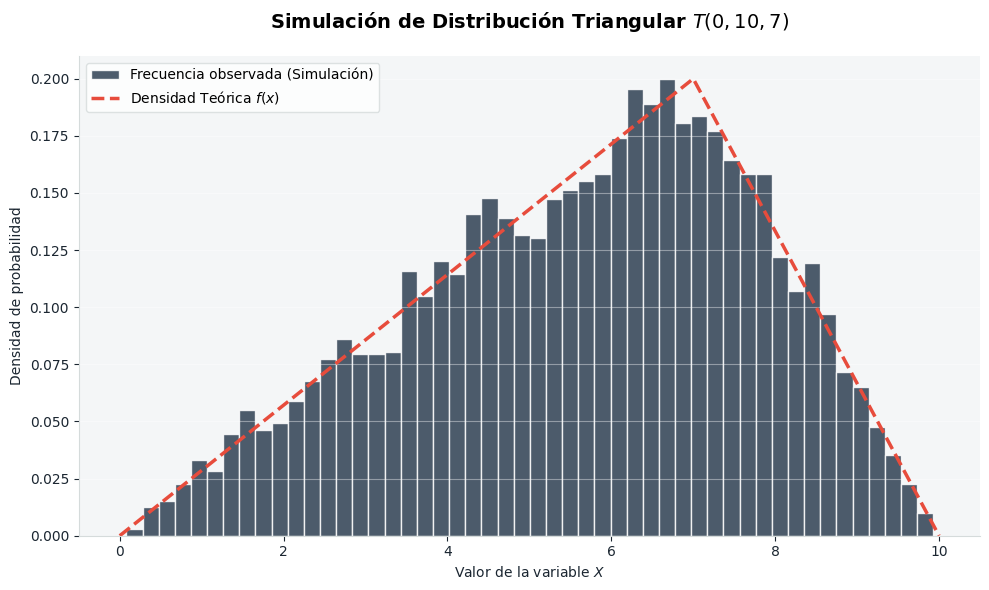

      ANÁLISIS DEL MÉTODO DE LA INVERSA      
Media Teórica        | 5.6667
Media Obtenida       | 5.6530
Error Absoluto       | 0.013645
---------------------------------------------


In [7]:
# Parámetros de la distribución triangular
a_tri, b_tri, c_tri = 0, 10, 7

# Generación de números U(0,1) usando el método congruencial
N = 10000
datos_u = fUniformeN(x0, a, b, m, N)

# Método de la Inversa para la Distribución Triangular
def inversa_triangular(u, a, b, c):
    fc = (c - a) / (b - a)  # Punto de corte en el eje U (h = 0.7)
    if u < fc:
        return a + np.sqrt(u * (b - a) * (c - a))
    else:
        return b - np.sqrt((1 - u) * (b - a) * (b - c))

# Aplicar la función a los datos generados
datos_triangular = [inversa_triangular(u, a_tri, b_tri, c_tri) for u in datos_u]

# Visualización
plt.figure(figsize=(10, 6))

# Histograma
plt.hist(datos_triangular, bins=50, density=True,
         color=PALETA['principal'], edgecolor='white', alpha=0.85,
         label='Frecuencia observada (Simulación)')

# Dibujar la densidad teórica
x_teorica = [a_tri, c_tri, b_tri]
y_teorica = [0, 2/(b_tri-a_tri), 0]
plt.plot(x_teorica, y_teorica, color=PALETA['teorico'], linestyle='--',
         lw=2.5, label='Densidad Teórica $f(x)$')

plt.title(f'Simulación de Distribución Triangular $T({a_tri}, {b_tri}, {c_tri})$', pad=20)
plt.xlabel('Valor de la variable $X$')
plt.ylabel('Densidad de probabilidad')
plt.legend(facecolor='white', edgecolor=PALETA['rejilla'])

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.grid(True, axis='y', alpha=0.4)

plt.tight_layout()
plt.show()

# Métricas
media_teorica = (a_tri + b_tri + c_tri) / 3
media_obtenida = np.mean(datos_triangular)

print("=" * 45)
print(f"{'ANÁLISIS DEL MÉTODO DE LA INVERSA':^45}")
print("=" * 45)
print(f"{'Media Teórica':<20} | {media_teorica:.4f}")
print(f"{'Media Obtenida':<20} | {media_obtenida:.4f}")
print(f"{'Error Absoluto':<20} | {abs(media_teorica - media_obtenida):.6f}")
print("-" * 45)

### 2.2. Método del Rechazo

Este procedimiento se basa en "encerrar" la función de densidad de probabilidad (PDF) deseada, $f(x)$, dentro de una función propuesta $g(x)$ (usualmente una distribución uniforme) multiplicada por una constante $M$, tal que $M \cdot g(x) \geq f(x)$ para todo el dominio.

### A. Parámetros y Función Techo
Para la distribución $T(0, 10, 7)$, el valor máximo de la densidad se alcanza en la moda ($c=7$):
* **Altura máxima ($h$):** $f(c) = \frac{2}{b-a} = \frac{2}{10} = 0.2$.
* **Función propuesta $g(x)$:** Utilizaremos una distribución uniforme $U(0, 10)$, cuya densidad es $g(x) = 1/10$.
* **Constante $M$:** Para asegurar que $M \cdot g(x) \geq f(x)$, igualamos $M \cdot (1/10) = 0.2$, de donde obtenemos $M = 2$.

### B. Algoritmo de Generación
El proceso para generar un valor válido sigue estos pasos:

1.  **Generar $X$:** Un candidato a partir de la distribución propuesta, $X \sim U(0, 10)$.
2.  **Generar $U$:** Una variable uniforme auxiliar para la decisión, $U \sim U(0, 1)$.
3. **Criterio de Aceptación:** Se acepta el valor de $X$ si se cumple la condición:
    
$$U \leq \frac{f(X)}{M \cdot g(X)}$$

Dado que $M \cdot g(X) = 2 \cdot \frac{1}{10} = 0.2$, la condición se simplifica multiplicando ambos lados por $0.2$:
> **Aceptar si: $U \cdot 0.2 \le f(X)$**

### C. Definición de la Condición según el Tramo
Debido a la naturaleza de la PDF de la distribución triangular, la evaluación de $f(X)$ depende de la región donde caiga el candidato:

* **Si $0 \leq X \leq 7$:**
    Se acepta si $U \cdot 0.2 \leq \frac{2X}{70}$
* **Si $7 < X \leq 10$:**
    Se acepta si $U \cdot 0.2 \leq \frac{2(10-X)}{30}$

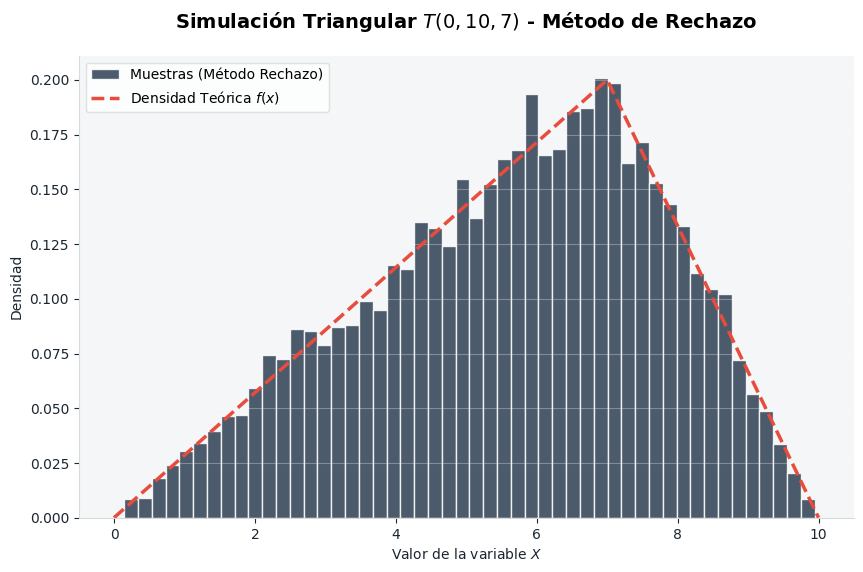

       ANÁLISIS DEL MÉTODO DE RECHAZO        
Media Teórica             | 5.6667
Media Obtenida            | 5.6602
Error Absoluto (Media)    | 0.006451
---------------------------------------------


In [16]:
# Configuración de Parámetros y Generador
N = 10000
x_actual = x0

def proximo_u01():
    """Utiliza el generador congruencial para devolver un número U(0,1)"""
    global x_actual
    x_actual = (x_actual * a + b) % m
    return x_actual / m

# Funciones del Método de Rechazo
def f_pdf_triangular(x, a, b, c):
    """Función de Densidad de Probabilidad T(a, b, c)"""
    if a <= x < c:
        return 2 * (x - a) / ((b - a) * (c - a))
    elif c <= x <= b:
        return 2 * (b - x) / ((b - a) * (b - c))
    else:
        return 0

def generar_triangular_rechazo(n, a, b, c):
    """Implementación del Método de Aceptación-Rechazo"""
    muestras = []
    ymax = 2 / (b - a)  # Altura máxima en la moda
    intentos_totales = 0

    while len(muestras) < n:
        intentos_totales += 1
        # 1. Generar candidato X en el soporte [a, b]
        u1 = proximo_u01()
        x_candidato = a + u1 * (b - a)

        # 2. Generar variable auxiliar U para la aceptación
        u2 = proximo_u01()
        y_limite = u2 * ymax

        # 3. Criterio de aceptación
        if y_limite <= f_pdf_triangular(x_candidato, a, b, c):
            muestras.append(x_candidato)

    return muestras, intentos_totales

# Ejecución de la Simulación
datos_rechazo, total_intentos = generar_triangular_rechazo(N, a_tri, b_tri, c_tri)

# Visualización
plt.figure(figsize=(10, 6))

# Histograma de los datos generados por rechazo
plt.hist(datos_rechazo, bins=50, density=True, color=PALETA['principal'],
         edgecolor='white', alpha=0.85, label='Muestras (Método Rechazo)')

# Superposición de la densidad teórica
x_plot = [a_tri, c_tri, b_tri]
y_plot = [0, 2/(b_tri-a_tri), 0]
plt.plot(x_plot, y_plot, color=PALETA['teorico'], linestyle='--',
         lw=2.5, label='Densidad Teórica $f(x)$')

# Estética y etiquetas
plt.title(f'Simulación Triangular $T({a_tri}, {b_tri}, {c_tri})$ - Método de Rechazo', pad=20)
plt.xlabel('Valor de la variable $X$')
plt.ylabel('Densidad')
plt.legend(facecolor='white', edgecolor=PALETA['rejilla'])
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.grid(True, axis='y', alpha=0.3)

plt.show()

# Análisis de Eficiencia y Métricas
media_teorica = (a_tri + b_tri + c_tri) / 3
media_rechazo = np.mean(datos_rechazo)

print("=" * 45)
print(f"{'ANÁLISIS DEL MÉTODO DE RECHAZO':^45}")
print("=" * 45)
print(f"{'Media Teórica':<25} | {media_teorica:.4f}")
print(f"{'Media Obtenida':<25} | {media_rechazo:.4f}")
print(f"{'Error Absoluto (Media)':<25} | {abs(media_teorica - media_rechazo):.6f}")
print("-" * 45)

## 3. Box-Müller.
Generar 1000 números pseudoaleatorios por el coseno y 1000 por el seno.
Verificar con los indicadores estadísticos que consideres, contrastes y representación gráfica que efectivamente los números generados se distribuyen como una Normal(0,1).

1. Para comprobar que está correctamente programado, generar 100 valores N(0,1). Éstos deben cumplir:

    * $\overline{x} = 0.02737136$
    * $S^2_n = 1.079609$
    * $S^2_{n-1} = 1.090514$
    * $u1 = 1.679040257 ~ u2 = −0.566059812 ~ u3 = 1.212934217 . . .$
    * $\overline{y} = −0.1220177$
    * $S^2_n = 1.040119$
    * $S^2_{n-1} = 1.050626$
    * $u1 = −0.47276880 ~ u2 = −0.23112413 ~ u3 = 0.53503714 . . .$  
    

2. Justificar que los números generados proceden de una distribución N(0,1).

### 3.1 Comprobacion para Box-Muller

In [9]:
# Función Box-Muller
def fBoxMuller(u_lista):
    u = np.array(u_lista)
    if len(u) % 2 != 0:
        u = u[:-1]

    u1 = u[0::2]
    u2 = u[1::2]

    term_radial = np.sqrt(-2 * np.log(u1))
    argumento_trig = 2 * np.pi * u2

    z_cos = term_radial * np.cos(argumento_trig)
    z_sen = term_radial * np.sin(argumento_trig)

    return z_cos, z_sen

# Función auxiliar para mostrar métricas
def mostrar_resultados(nombre, datos):
    media = np.mean(datos)
    var_s = np.var(datos)
    var_i = np.var(datos, ddof=1)

    print(f"Métricas para la Normal del {nombre}:")
    print(f"  mean    = {media:.8f}")
    print(f"  S^2_n   = {var_s:.6f}")
    print(f"  S^2_n-1 = {var_i:.6f}")
    print(f"  Valores iniciales: {datos[0]:.9f}, {datos[1]:.9f}, {datos[2]:.9f}...")
    print("-" * 45)

# Generación de Datos
N_sim = 200
x0 = 123456789
u_lista = fUniformeN(x0, a, b, m, N_sim)
z_cos, z_sen = fBoxMuller(u_lista)

# Ejecución de los resultados
print("=" * 45)
print(f"{'RESULTADOS BOX-MULLER':^45}")
print("=" * 45)
mostrar_resultados("Coseno (X)", z_cos)
mostrar_resultados("Seno (Y)", z_sen)


            RESULTADOS BOX-MULLER            
Métricas para la Normal del Coseno (X):
  mean    = 0.02737136
  S^2_n   = 1.079609
  S^2_n-1 = 1.090514
  Valores iniciales: 1.679040257, -0.566059812, 1.212934217...
---------------------------------------------
Métricas para la Normal del Seno (Y):
  mean    = -0.12201765
  S^2_n   = 1.040119
  S^2_n-1 = 1.050626
  Valores iniciales: -0.472768800, -0.231124131, 0.535037137...
---------------------------------------------


### 3.2 Justificacion Box-Muller

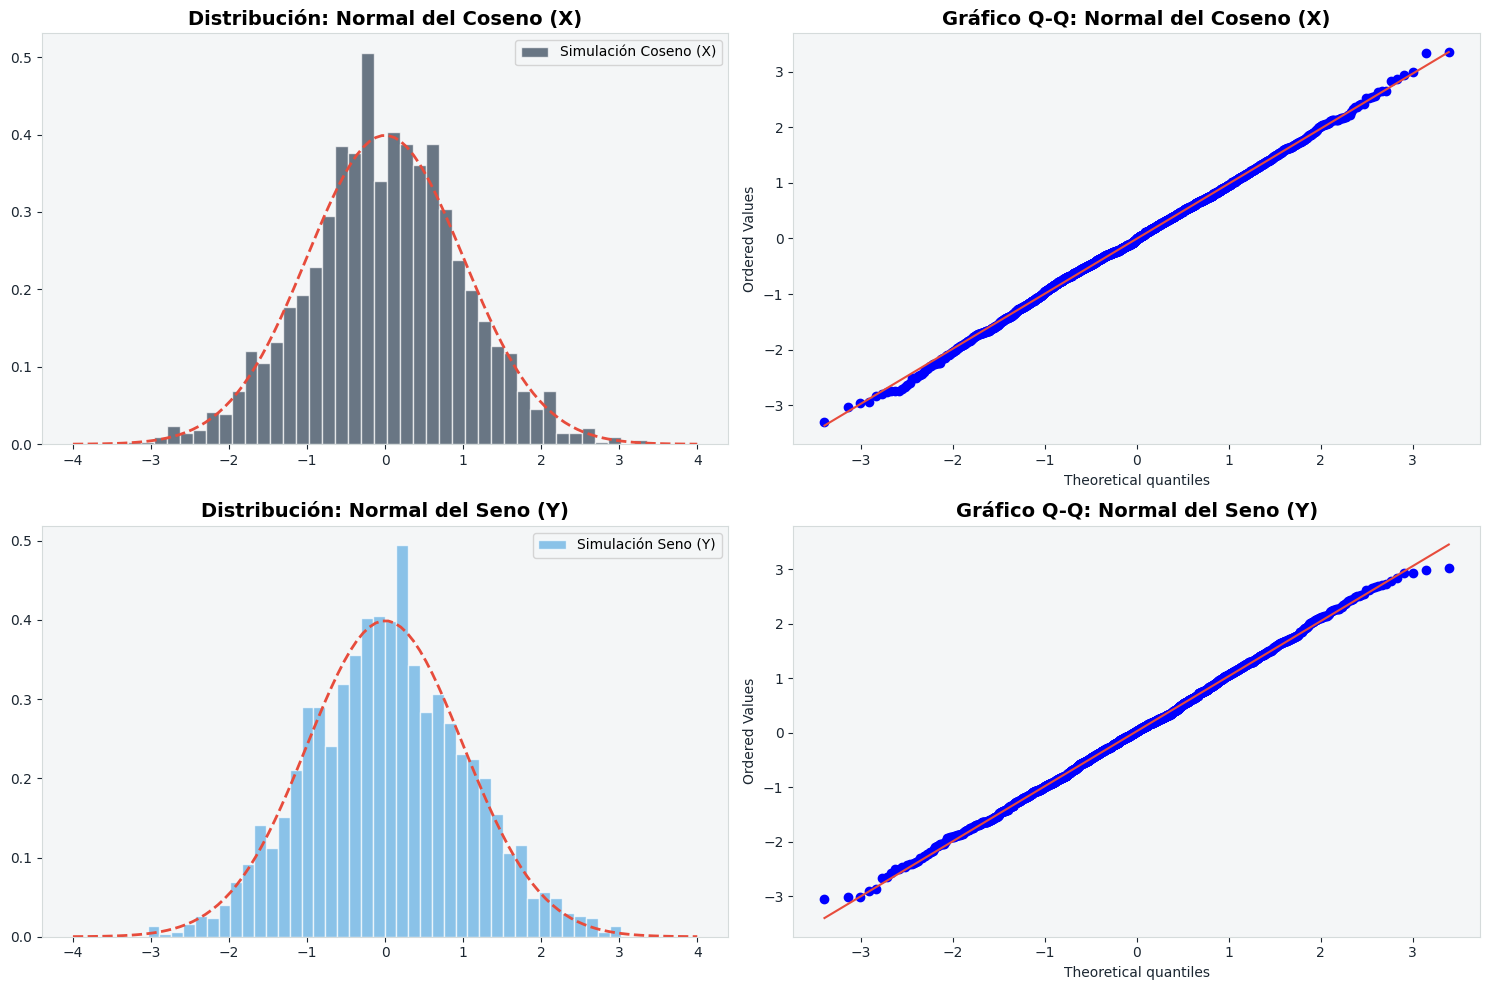

         MÉTRICAS Y VALIDACIÓN ESTADÍSTICA (N=2000)         
Componente      | Media        | Cuasivarianza   | p-valor   
------------------------------------------------------------
Coseno (X)      |    -0.006950 |        0.978312 |   0.338083
Seno (Y)        |     0.027356 |        1.017885 |   0.282284
------------------------------------------------------------


In [10]:
# Preparación de datos
N_sup = 4000 # Generamos 4000 uniformes -> 2000 cos y 2000 sen
u_lista_sup = fUniformeN(x0, a, b, m, N_sup)
z_cos, z_sen = fBoxMuller(u_lista_sup)

# Función de validación visual comparativa
def comparar_normales(z_x, z_y):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    datasets = [z_x, z_y]
    nombres = ['Coseno (X)', 'Seno (Y)']
    colores = [PALETA['principal'], PALETA['secundario']]

    for i, data in enumerate(datasets):
        # Histogramas
        axes[i, 0].hist(data, bins=40, density=True, color=colores[i],
                        edgecolor='white', alpha=0.7, label=f'Simulación {nombres[i]}')
        x = np.linspace(-4, 4, 100)
        axes[i, 0].plot(x, stats.norm.pdf(x, 0, 1), color=PALETA['teorico'], lw=2, linestyle='--')
        axes[i, 0].set_title(f'Distribución: Normal del {nombres[i]}')
        axes[i, 0].legend()

        # Gráficos Q-Q
        stats.probplot(data, dist="norm", plot=axes[i, 1])
        axes[i, 1].get_lines()[1].set_color(PALETA['teorico'])
        axes[i, 1].set_title(f'Gráfico Q-Q: Normal del {nombres[i]}')

    plt.tight_layout()
    plt.show()

    # Cálculo de métricas y Test estadístico
    print("=" * 60)
    print(f"{'MÉTRICAS Y VALIDACIÓN ESTADÍSTICA (N=' + str(len(z_x)) + ')':^60}")
    print("=" * 60)
    print(f"{'Componente':<15} | {'Media':<12} | {'Cuasivarianza':<15} | {'p-valor':<10}")
    print("-" * 60)

    for nombre, data in zip(nombres, datasets):
        media = np.mean(data)
        cuasivar = np.var(data, ddof=1) # S^2_{n-1}
        _, p_val = stats.shapiro(data)

        print(f"{nombre:<15} | {media:12.6f} | {cuasivar:15.6f} | {p_val:10.6f}")

    print("-" * 60)

# Ejecutar validación
comparar_normales(z_cos, z_sen)

Para verificar la robustez del método de Box-Muller, se ha incrementado el tamaño de la muestra, permitiendo un análisis estadístico más profundo de las dos variables generadas: la componente del **Coseno ($X$)** y la del **Seno ($Y$)**.

### A. Métricas Descriptivas
Se evalúa si los datos se centran en el origen y mantienen la dispersión unitaria característica de una $N(0,1)$. Para la simulación de gran escala, se obtienen valores muy próximos a los parámetros teóricos:

| Componente | Media ($\bar{x}$) | Varianza ($S^2_{n-1}$) | Esperado |
| :--- | :--- | :--- | :--- |
| **Normal Coseno (X)** | -0.00695 | 0.978312 | (0, 1) |
| **Normal Seno (Y)** | 0.027356 | 1.017885 | (0, 1) |

### B. Análisis Gráfico: Histograma y Gráfico Q-Q
La inspección visual es fundamental para confirmar la morfología de la distribución:

1.  **Histogramas de Densidad:** En ambos casos, las barras de frecuencia se ajustan con precisión a la campana de Gauss teórica (línea discontinua roja). No se observan sesgos significativos ni colas pesadas fuera de lo común.
2.  **Gráficos Q-Q (Cuantil-Cuantil):** Los puntos azules (cuantiles observados) se alinean casi perfectamente sobre la recta de referencia de 45°. Esta coincidencia lineal demuestra que la distribución de los datos simulados es relamente muy parecida a la distribución normal.

### C. Contrastes de Hipótesis (Prueba de Normalidad)
Se aplica el test de **Shapiro-Wilk** para dotar de rigor estadístico a la observación visual. Las hipótesis planteadas son:
* $H_0$: Los datos proceden de una población con distribución normal $N(0,1)$

* $H_1$: Los datos proceden de una población con una distribución distinta a la normal.

Dado que ambos p-valores: **P-valor (Coseno X):** $0.338083$ y **P-valor (Seno Y):** $0.282284$ son superiores al nivel de significación estándar ($\alpha = 0.05$), **no existe evidencia estadística suficiente para rechazar la hipótesis nula**. Por lo tanto, se asume que los datos son compatibles con una distribución **Normal estándar $N(0,1)$**, confirmando que las desviaciones observadas respecto a la campana teórica entran dentro del margen de la variabilidad aleatoria esperada.


## 4. Método Marsaglia
Generar 1000 pares de números pseudoaleatorios Normal(0,1).

1. Para comprobar que está correctamente programado, generar 100 valores N(0,1). Éstos deben cumplir:

    * $\overline{x} = 0.2159052$
    * $S^2_n = 0.7075141$
    * $S^2_{n-1} = 0.7146607$
    * $u1 = 1.24295692 ~ u2 = −0.13445768 ~ u3 = −0.30786186 . . .$
    * $\overline{y} = −0.1732801$
    * $S^2_n = 0.9229105$
    * $S^2_{n-1} = 0.9322328$
    * $u1 = 0.23272421 ~ u2 = −0.68882581 ~ u3 = −0.49533179 . . .$
    
    
2. Justificar que los números generados proceden de una distribución N(0,1).

### 4.1 Comprobación para Marsaglia

In [11]:
# Funcion de Marsaglia
def fMarsaglia(n_objetivo, x, a, b, m):
    x1_lista = []
    x2_lista = []
    x_curr = x
    intentos = 0

    while (len(x1_lista) + len(x2_lista)) < n_objetivo:
        intentos += 1

        # Generamos u1 y u2
        x_curr = (a * x_curr + b) % m
        u1 = x_curr / m

        x_curr = (a * x_curr + b) % m
        u2 = x_curr / m

        # Paso 2
        v1 = 2 * u1 - 1
        v2 = 2 * u2 - 1
        R2 = v1**2 + v2**2

        # Paso 3: Criterio (R2 > 1)
        if R2 > 1 or R2 == 0:
            continue

        # Paso 4
        y_factor = np.sqrt((-2 * np.log(R2)) / R2)
        x1_lista.append(v1 * y_factor)
        x2_lista.append(v2 * y_factor)

    return np.array(x1_lista), np.array(x2_lista), intentos


# Parametros
n_norm_objetivo = 200
x1_res, x2_res, total_it = fMarsaglia(n_norm_objetivo, x0, a, b, m)

# Función para imprimir
def imprimir_control_marsaglia(nombre, datos):
    print(f"Indicadores para {nombre}:")
    print(f"  Media (x_bar) = {np.mean(datos):.7f}")
    print(f"  S^2_n         = {np.var(datos):.7f}")
    print(f"  S^2_n-1       = {np.var(datos, ddof=1):.7f}")
    print(f"  u1, u2, u3... = {', '.join([f'{val:.8f}' for val in datos[:3]])}")
    print("-" * 50)

# Resultados
print("=" * 55)
print(f"{'RESULTADOS MARSAGLIA':^55}")
print("=" * 55)

imprimir_control_marsaglia("Secuencia X (x1)", x1_res)
imprimir_control_marsaglia("Secuencia Y (x2)", x2_res)


                 RESULTADOS MARSAGLIA                  
Indicadores para Secuencia X (x1):
  Media (x_bar) = 0.2159052
  S^2_n         = 0.7075141
  S^2_n-1       = 0.7146607
  u1, u2, u3... = 1.24295692, -0.13445768, -0.30786186
--------------------------------------------------
Indicadores para Secuencia Y (x2):
  Media (x_bar) = -0.1732801
  S^2_n         = 0.9229105
  S^2_n-1       = 0.9322328
  u1, u2, u3... = 0.23272421, -0.68882581, -0.49533180
--------------------------------------------------


### 4.2 Justificación para Marsaglia

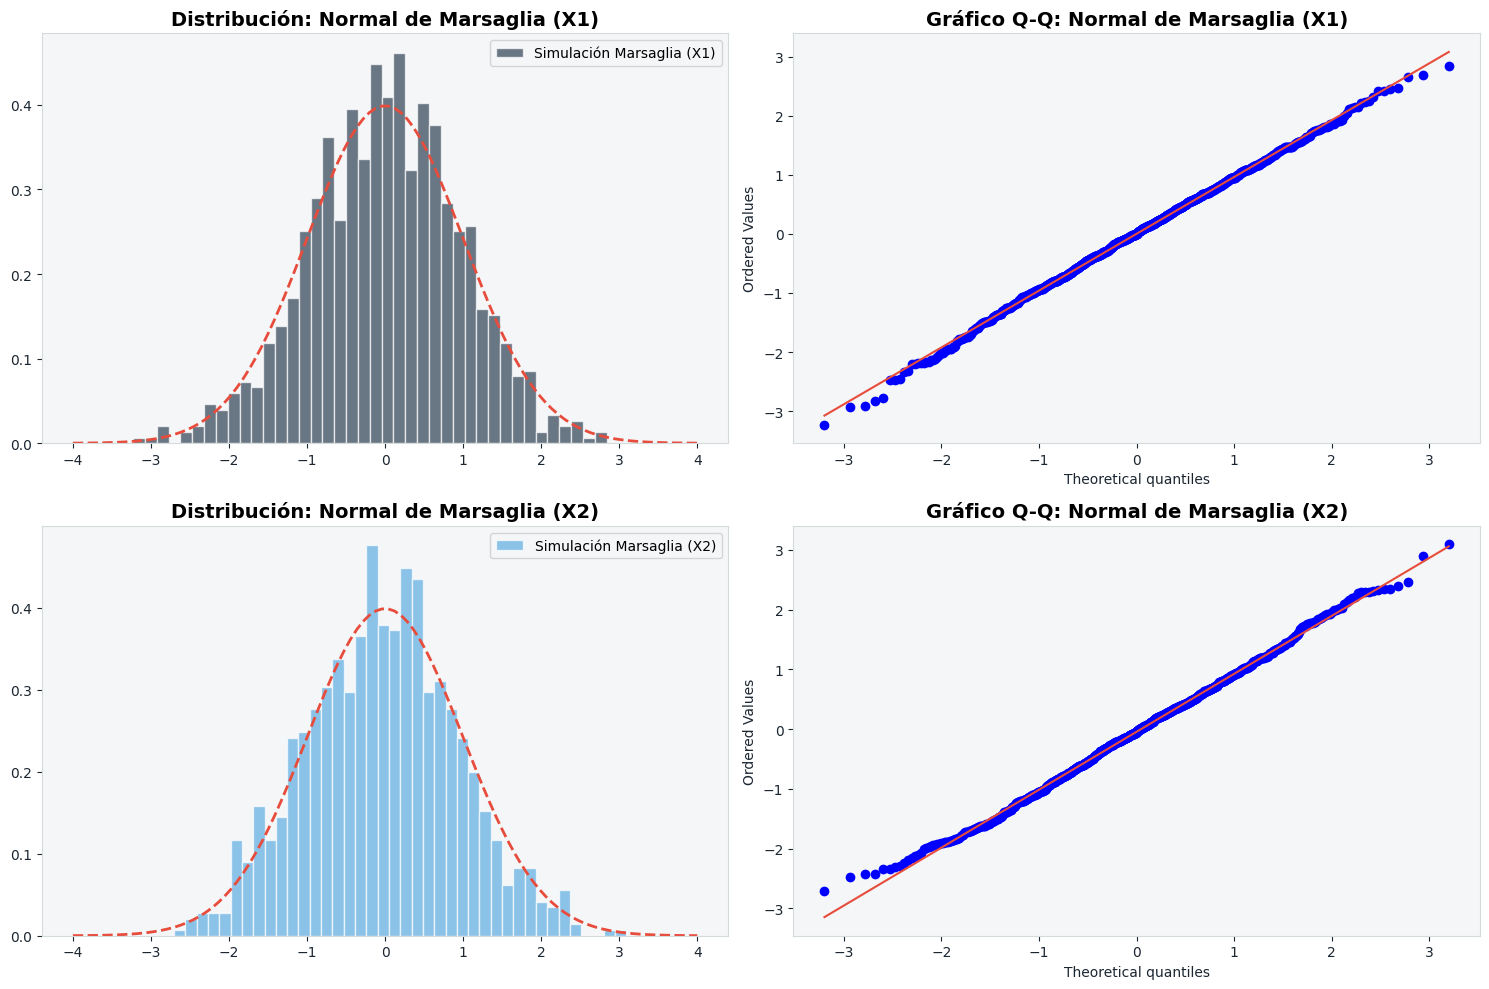

                    MÉTRICAS Y MULTI-CONTRASTE DE NORMALIDAD (N=1000 pares)                    
Componente      | Media      | Cuasivar   | P-Shapiro    | P-D'Agost    | P-KS      
-----------------------------------------------------------------------------------------------
Marsaglia (X1)  |    0.00225 |    0.92374 |     0.715055 |     0.357360 |   0.731330
Marsaglia (X2)  |   -0.04216 |    0.93893 |     0.220626 |     0.340909 |   0.230791


In [12]:
# Preparación de datos (1000 pares = 2000 valores totales)
n_objetivo_pares = 2000
x1_sup, x2_sup, total_it = fMarsaglia(n_objetivo_pares, x0, a, b, m)

# Función de validación
def comparar_marsaglia(z_x1, z_x2):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    datasets = [z_x1, z_x2]
    nombres = ['Marsaglia (X1)', 'Marsaglia (X2)']
    colores = [PALETA['principal'], PALETA['secundario']]

    for i, data in enumerate(datasets):
        # Histogramas con densidad teórica
        axes[i, 0].hist(data, bins=40, density=True, color=colores[i],
                        edgecolor='white', alpha=0.7, label=f'Simulación {nombres[i]}')
        x = np.linspace(-4, 4, 100)
        axes[i, 0].plot(x, stats.norm.pdf(x, 0, 1), color=PALETA['teorico'], lw=2, linestyle='--')
        axes[i, 0].set_title(f'Distribución: Normal de {nombres[i]}')
        axes[i, 0].legend()

        # Gráficos Q-Q para validar colas y cuantiles
        stats.probplot(data, dist="norm", plot=axes[i, 1])
        axes[i, 1].get_lines()[1].set_color(PALETA['teorico'])
        axes[i, 1].set_title(f'Gráfico Q-Q: Normal de {nombres[i]}')

    plt.tight_layout()
    plt.show()

    # Tests Estadísticos
    print("=" * 95)
    print(f"{'MÉTRICAS Y MULTI-CONTRASTE DE NORMALIDAD (N=' + str(len(z_x1)) + ' pares)':^95}")
    print("=" * 95)
    header = f"{'Componente':<15} | {'Media':<10} | {'Cuasivar':<10} | {'P-Shapiro':<12} | {'P-D\'Agost':<12} | {'P-KS':<10}"
    print(header)
    print("-" * 95)

    for nombre, data in zip(nombres, datasets):
        media = np.mean(data)
        cuasivar = np.var(data, ddof=1)
        _, p_shapiro = stats.shapiro(data)
        _, p_dagostino = stats.normaltest(data)
        _, p_ks = stats.kstest(data, 'norm', args=(0, 1))

        fila = f"{nombre:<15} | {media:10.5f} | {cuasivar:10.5f} | {p_shapiro:12.6f} | {p_dagostino:12.6f} | {p_ks:10.6f}"
        print(fila)

# Ejecutar validación
comparar_marsaglia(x1_sup, x2_sup)

Para validar la precisión del **método de Marsaglia**, se ha realizado un análisis estadístico exhaustivo sobre los 1000 pares de variables aceptados por el algoritmo, analizando de forma independiente la **Componente $X_1$** y la **Componente $X_2$**.

### A. Métricas Descriptivas
Se evalúa si el proceso de aceptación-rechazo preserva los momentos de la distribución normal estándar. Los resultados obtenidos muestran una convergencia sólida hacia los valores teóricos:

| Componente | Media ($\bar{x}$) | Cuasivarianza ($S^2_{n-1}$) | Esperado |
| :--- | :--- | :--- | :--- |
| **Normal Marsaglia ($X_1$)** | 0.002250 | 0.923740 | (0, 1) |
| **Normal Marsaglia ($X_2$)** | -0.042160 | 0.938930 | (0, 1) |

### B. Análisis Gráfico: Histograma y Gráfico Q-Q
La inspección visual permite confirmar que el descarte de puntos fuera del círculo unidad no altera la morfología de la distribución final:

1.  **Histogramas de Densidad:** Las muestras generadas se ajustan a la campana de Gauss teórica. La densidad de los datos aceptados refleja la simetría esperada sin presentar deformaciones en los flancos de la distribución.
2.  **Gráficos Q-Q (Cuantil-Cuantil):** La alineación de los cuantiles observados con la recta de 45° es consistente en ambas componentes.

### C. Contrastes de Hipótesis (Multi-contraste de Normalidad)
Para dotar de rigor estadístico a la simulación, se han aplicado tres pruebas de distinta naturaleza para garantizar la robustez del generador. Las hipótesis generales para estos contrastes son:

* $H_0$: Los datos proceden de una población con distribución normal estándar $N(0,1)$.
* $H_1$: Los datos proceden de una población con una distribución distinta.

| Test Estadístico | P-valor ($X_1$) | P-valor ($X_2$) | Resultado ($\alpha = 0.05$) |
| :--- | :--- | :--- | :--- |
| **Shapiro-Wilk** | 0.7150 | 0.2206 | No se rechaza $H_0$ |
| **D'Agostino-Pearson** | 0.3573 | 0.3409 | No se rechaza $H_0$ |
| **Kolmogorov-Smirnov** | 0.7313 | 0.2307 | No se rechaza $H_0$ |

Dado que todos los p-valores obtenidos son significativamente superiores al nivel de significación estándar ($\alpha = 0.05$), **no existe evidencia estadística suficiente para rechazar la hipótesis nula**. Se concluye que el algoritmo genera variables aleatorias independientes y distribuidas según una **Normal estándar $N(0,1)$**, confirmando que la variabilidad observada es puramente estocástica.

## 5. Box-Müller antitéticas

## 6. Marsaglia antitéticas

## 7. t-Student

funcion para la chi
funcion para la gamma
para n = 6, n = 20 y n = 40 y graficarlo pra ver que evoluciona hacia una normal

porque la t-student cuando tenemos muestras pequeñas, si crece el numero de observaciones coincide una normal

## 8. Generar 1000 muestras de tamaño 20 de la Normal:
$N(\mu=7,\sigma=2)$  

•	Suponiendo media y varianza desconocidas, obtener a partir de cada una de las 1000 muestras el intervalo de confianza para la media al nivel $\alpha = 0.05$.   
•	Contar cuántos de los 1000 intervalos de confianza contienen al verdadero valor ($\mu=7$) de la media.

In [13]:
# Parámetros del ejercicio
mu_real = 7
sigma_real = 2
n_muestra = 20
total_muestras = 1000
alpha = 0.05

# Generación de datos N(7, 2)
# Generamos 20,000 uniformes para obtener 10,000 de z_cos y 10,000 de z_sen
N_total_datos = total_muestras * n_muestra
u_lista = fUniformeN(x0, a, b, m, N_total_datos)
z_cos, z_sen = fBoxMuller(u_lista)

# Concatenamos las dos fuentes de normal estándar
z_estandar = np.concatenate([z_cos, z_sen])

# Transformamos a la normal deseada: X = mu + sigma * Z
datos_x = mu_real + sigma_real * z_estandar

# Construcción de Intervalos y Validación
exitos = 0
intervalos_ejemplo = []

for i in range(total_muestras):
    # Extraemos el bloque de 20 datos para la muestra i
    inicio = i * n_muestra
    fin = inicio + n_muestra
    muestra = datos_x[inicio:fin]

    # Estadísticos muestrales
    x_barra = np.mean(muestra)
    s = np.std(muestra, ddof=1) # Cuasidesviación típica (s)

    # Valor crítico t-Student (n-1 = 19 grados de libertad)
    t_critico = stats.t.ppf(1 - alpha/2, n_muestra - 1)

    # Error estándar y margen de error
    error_estandar = s / np.sqrt(n_muestra)
    margen_error = t_critico * error_estandar

    lim_inf = x_barra - margen_error
    lim_sup = x_barra + margen_error

    # Verificación: ¿Contiene el intervalo al valor real mu=7?
    if lim_inf <= mu_real <= lim_sup:
        exitos += 1

    # Guardamos los primeros ejemplos para visualización
    if i < 3:
        intervalos_ejemplo.append((i+1, x_barra, lim_inf, lim_sup))

# Resultados
print("=" * 65)
print(f"{'SIMULACIÓN DE INTERVALOS DE CONFIANZA N(7, 2)':^65}")
print("=" * 65)
print(f"Resultados de la simulación:")
print(f"  - Total de muestras: {total_muestras}")
print(f"  - Tamaño de cada muestra (n): {n_muestra}")
print(f"  - Nivel de confianza: {1 - alpha:.2f}")
print(f"  - Éxitos (mu=7 contenido): {exitos}")
print(f"  - Proporción de cobertura: {exitos/total_muestras:.4f}")
print("-" * 65)

print("Ejemplos de los primeros intervalos calculados:")
for num, media, inf, sup in intervalos_ejemplo:
    status = "SÍ" if inf <= mu_real <= sup else "NO"
    print(f"Muestra {num}: Media={media:.4f} | IC=[{inf:.4f}, {sup:.4f}] | ¿Contiene mu=7?: {status}")
print("=" * 65)


          SIMULACIÓN DE INTERVALOS DE CONFIANZA N(7, 2)          
Resultados de la simulación:
  - Total de muestras: 1000
  - Tamaño de cada muestra (n): 20
  - Nivel de confianza: 0.95
  - Éxitos (mu=7 contenido): 942
  - Proporción de cobertura: 0.9420
-----------------------------------------------------------------
Ejemplos de los primeros intervalos calculados:
Muestra 1: Media=7.3720 | IC=[6.2427, 8.5013] | ¿Contiene mu=7?: SÍ
Muestra 2: Media=6.9171 | IC=[5.8403, 7.9939] | ¿Contiene mu=7?: SÍ
Muestra 3: Media=7.3678 | IC=[6.7315, 8.0041] | ¿Contiene mu=7?: SÍ


El experimento de validación mediante la construcción de intervalos de confianza para una población $N(7, 2)$ presenta resultados que sugieren una consistencia con la teoría estadística, basándose en las siguientes observaciones:

*   **Proximidad de la Cobertura:** La proporción de cobertura obtenida (**0.9420**) tiende hacia el nivel de confianza teórico configurado del **95%** ($\alpha = 0.05$). Esta diferencia de 0.8% parece compatible con la variabilidad estocástica inherente a un experimento de 1000 muestras.
*   **Comportamiento del Estimador:** El empleo de la **cuasivarianza** ($S^2_{n-1}$) junto al valor crítico de la **t-Student** ($\nu = 19$) parece mitigar la incertidumbre sobre la varianza poblacional desconocida. Los casos analizados sugieren que los intervalos muestran una adaptación dinámica según la dispersión de cada muestra, facilitando la inclusión del parámetro real $\mu = 7$ en la mayoría de las iteraciones.


## 9. Generar una muestra aleatoria simple de una normal multivariante de dimensión 3 y con matriz de covarianzas correladas.

In [14]:
# Definición de Parámetros
# Vector de medias mu (Dimensión 3)
mu = np.array([5.0, 10.0, -2.0])

# Matriz de varianza-covarianza Correlada (Sigma)
sigma = np.array([
    [1.0, 0.8, 0.4],  # Var(X1)=1, Cov(X1,X2)=0.8
    [0.8, 2.0, 0.5],  # Var(X2)=2, Cov(X2,X3)=0.5
    [0.4, 0.5, 1.5]   # Var(X3)=1.5
])

# Generación de Normales Estándar
# Para N=1000 muestras de dimensión 3, necesitamos 3000 valores
N_mas = 1000
u_base = fUniformeN(x0, a, b, m, N_mas * 3)
z_c, z_s = fBoxMuller(u_base)

# Concatenamos y formamos la matriz (3, 1000)
z_total = np.concatenate([z_c, z_s])[:N_mas * 3]
Z = z_total.reshape(3, N_mas)

# Método de Cholesky
# Buscamos L tal que L * L^T = Sigma
L = np.linalg.cholesky(sigma)

# Transformación Multivariante: X = mu + L * Z
X_multivariante = mu[:, np.newaxis] + L @ Z

# Transponemos para tener N filas y 3 columnas
muestra_final = X_multivariante.T

# Validación de Resultados
cov_muestral = np.cov(muestra_final, rowvar=False)

print("-" * 55)
print(f"{'GENERACIÓN MULTIVARIANTE (N=' + str(N_mas) + ')':^55}")
print("-" * 55)
print("Matriz de Covarianza Teórica (V):")
print(sigma)
print("\nMatriz de Covarianza Muestral (Estimada):")
print(np.round(cov_muestral, 3))
print("-" * 55)
print(f"Media Teórica: {mu}")
print(f"Media Muestral: {np.round(np.mean(muestra_final, axis=0), 3)}")
print("-" * 55)

-------------------------------------------------------
           GENERACIÓN MULTIVARIANTE (N=1000)           
-------------------------------------------------------
Matriz de Covarianza Teórica (V):
[[1.  0.8 0.4]
 [0.8 2.  0.5]
 [0.4 0.5 1.5]]

Matriz de Covarianza Muestral (Estimada):
[[0.998 0.782 0.396]
 [0.782 1.868 0.462]
 [0.396 0.462 1.522]]
-------------------------------------------------------
Media Teórica: [ 5. 10. -2.]
Media Muestral: [ 5.006  9.981 -1.918]
-------------------------------------------------------


El experimento de generación multivariante mediante el método de Cholesky presenta resultados que sugieren una coherencia con el modelo teórico propuesto, basándose en los siguientes puntos:

*   **Estructura de Dependencia:** La matriz de covarianza estimada tiende a aproximarse a los valores teóricos. Se observa una captura cercana de la correlación entre $X_1$ y $X_2$ (valor obtenido de 0.782 frente al 0.8 teórico) y una estabilidad relativa de las varianzas en las tres dimensiones.
*   **Localización del Centroide:** El vector de medias muestrales $[5.006, 9.981, -1.918]$ muestra desviaciones reducidas respecto al vector de medias poblacionales $[5, 10, -2]$.

**Resumen de Desviaciones Observadas:**
*   **Error máximo en medias:** ~0.082 ($X_3$).
*   **Error máximo en covarianzas:** ~0.038 ($X_2, X_3$).

Estos márgenes parecen compatibles con el tamaño de muestra de $N=1000$, aportando indicios sobre la robustez del modelo implementado para esta simulación.

## 10. Determinar por los dos métodos de Monte Carlo la integral siguiente:

$$ I=\int_1^4 (x^2+2x)dx \hspace{1cm};\hspace{1cm} I=36$$

* Determinar el tamaño muestral $n$ de forma que con probabilidad menor de $\alpha = 0.05$ el valor absoluto entre la estimación de la integral y el valor real sea menor que $\epsilon = 0.1$.

* Utilizar dos procedimientos: Considerar la aproximación de Tchebychev y la normal.

* Construir una tabla comparativa entre los resultados obtenidos por los 2 métodos y considerando los 2 valores óptimos de $n$.
